In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Dataset information
df.info()

# Statistical summary
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
gender_survival = df.groupby("Sex")["Survived"].mean()

print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [ ]:
class_survival = df.groupby("Pclass")["Survived"].mean()

print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [ ]:
bins = [0,12,18,35,60,100]
labels = ["Child","Teen","Young Adult","Adult","Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_survival = df.groupby("AgeGroup")["Survived"].mean()

print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_7097/3903392487.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


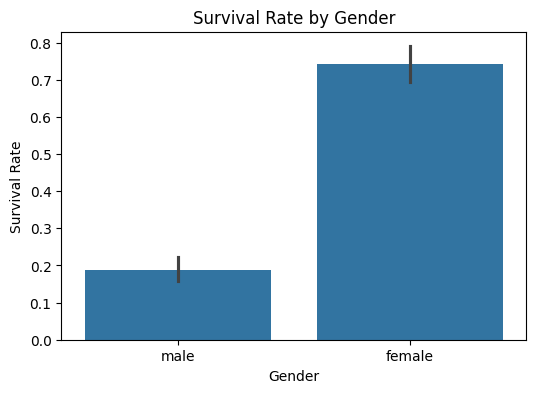

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

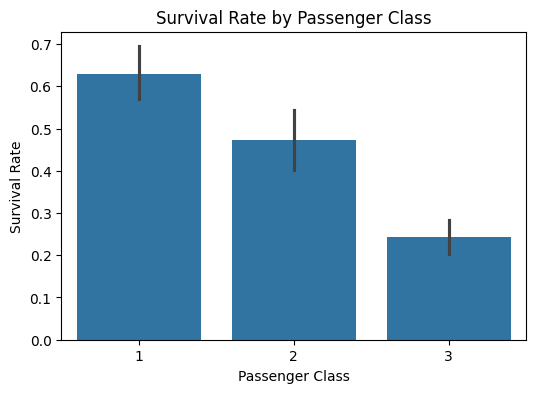

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

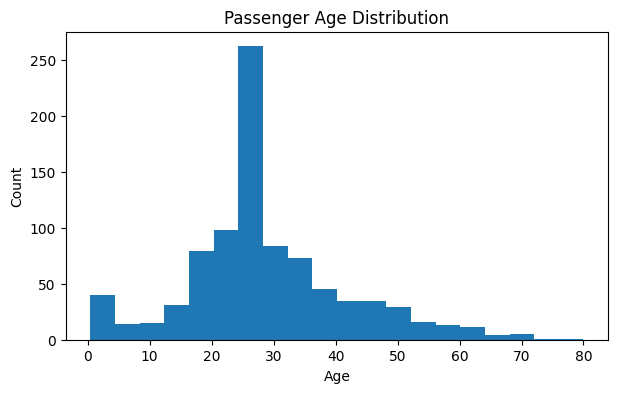

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df["Age"], bins=20)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [ ]:
print("---------- Insights ----------")

print("1. Female passengers had a higher survival rate than male passengers.")
print("2. First-class passengers had the highest survival rate.")
print("3. Third-class passengers had the lowest survival rate.")
print("4. Children survived more often than adults.")
print("5. Most passengers were between 20 and 40 years old.")

---------- Insights ----------
1. Female passengers had a higher survival rate than male passengers.
2. First-class passengers had the highest survival rate.
3. Third-class passengers had the lowest survival rate.
4. Children survived more often than adults.
5. Most passengers were between 20 and 40 years old.
